In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [5]:
sentiment = pd.read_csv("/Users/diyakd/Desktop/trader-sentiment-analysis/data/fear_greed_index.csv")
trades = pd.read_csv("/Users/diyakd/Desktop/trader-sentiment-analysis/data/historical_data.csv")

In [6]:
sentiment.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
print(sentiment.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


In [8]:
sentiment.columns
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [9]:
sentiment.info()
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

In [10]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [11]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [12]:
trades = trades.dropna()

In [13]:
sentiment.duplicated().sum()

np.int64(0)

In [14]:
trades.duplicated().sum()

np.int64(0)

In [15]:
trades = trades.drop_duplicates()

In [17]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [19]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.date

In [20]:
trades[['Timestamp IST','date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [21]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [22]:
df = trades.merge(sentiment[['date','classification']], on='date', how='left')

In [23]:
df[['date','classification']].head()

,date,classification
0,2024-12-02,NaN
1,2024-12-02,NaN
2,2024-12-02,NaN
3,2024-12-02,NaN
4,2024-12-02,NaN


In [24]:
sentiment[['timestamp','date','classification']].head()

,timestamp,date,classification
0,1517463000,2018-02-01,Fear
1,1517549400,2018-02-02,Extreme Fear
2,1517635800,2018-02-03,Fear
3,1517722200,2018-02-04,Extreme Fear
4,1517808600,2018-02-05,Extreme Fear


In [25]:
trades['date'].min(), trades['date'].max()

(datetime.date(2023, 5, 1), datetime.date(2025, 5, 1))

In [26]:
sentiment['date'].min(), sentiment['date'].max()

('2018-02-01', '2025-05-02')

In [27]:
trades['date'].dtype

dtype('O')

In [28]:
sentiment['date'].dtype

dtype('O')

In [29]:
trades['date'] = pd.to_datetime(trades['date'])
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [30]:
df = trades.merge(sentiment[['date','classification']], on='date', how='left')

In [31]:
df[['date','classification']].head()

,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [32]:
df['classification'].isna().sum()

np.int64(6)

In [33]:
df.shape

(211224, 18)

In [34]:
pnl_sentiment = df.groupby('classification')['Closed PnL'].mean().reset_index()

print(pnl_sentiment)

  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718


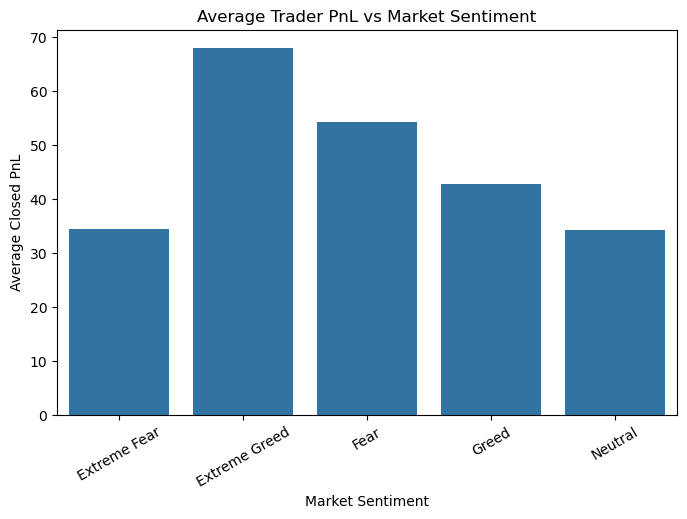

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(data=pnl_sentiment, x='classification', y='Closed PnL')

plt.title("Average Trader PnL vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=30)

plt.show()

In [36]:
trade_freq = df.groupby(['date','classification']).size().reset_index(name='trade_count')

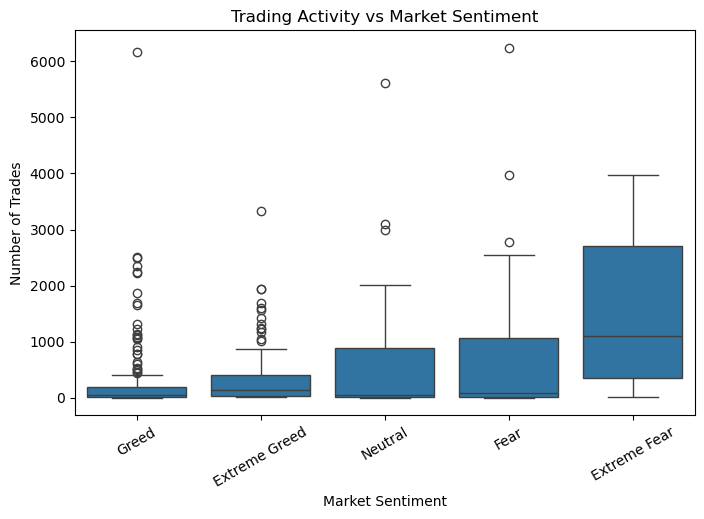

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(data=trade_freq, x='classification', y='trade_count')

plt.title("Trading Activity vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=30)

plt.show()

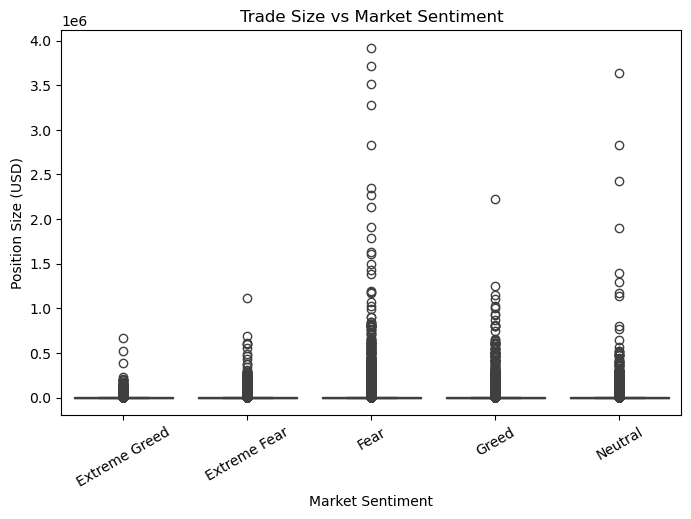

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='classification', y='Size USD')

plt.title("Trade Size vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Position Size (USD)")

plt.xticks(rotation=30)

plt.show()

In [39]:
trade_counts = df['Account'].value_counts()

threshold = trade_counts.median()

df['trader_segment'] = df['Account'].map(
    lambda x: 'Frequent Trader' if trade_counts[x] > threshold else 'Infrequent Trader'
)

In [40]:
segment_pnl = df.groupby('trader_segment')['Closed PnL'].mean()

print(segment_pnl)

trader_segment
Frequent Trader      42.493421
Infrequent Trader    96.943024
Name: Closed PnL, dtype: float64


In [41]:
df['win'] = df['Closed PnL'] > 0

win_rate = df.groupby('classification')['win'].mean()

print(win_rate)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64
